# Lab 6 - LSTM và GRU dự đoán Vietlott 6/55

Notebook này được viết theo cấu trúc Kaggle và dùng file `result.csv` để xây dựng hai mô hình **LSTM** và **GRU** dự đoán kết quả Vietlott 6/55.

**Lưu ý học thuật:** xổ số là quá trình gần như ngẫu nhiên, nên mục tiêu chính của bài là rèn luyện quy trình xử lý dữ liệu chuỗi thời gian, thiết kế mô hình hồi quy/gated recurrent và đánh giá kết quả. Không nên hiểu kết quả dự đoán như một khuyến nghị chơi xổ số.

## 1. Thiết lập môi trường Kaggle

- Kaggle thường đã có sẵn `numpy`, `pandas`, `matplotlib`, `scikit-learn`, `torch`.
- Notebook tự chọn `cuda` nếu có GPU, còn không sẽ chạy CPU bình thường.
- Đường dẫn dữ liệu được tự dò trong `/kaggle/input`, hoặc fallback về thư mục local khi chạy trên máy cá nhân.

In [1]:
# Nếu Kaggle thiếu thư viện, có thể mở comment dòng dưới.
# !pip install -q torch numpy pandas matplotlib scikit-learn

import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import hamming_loss

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Thiết bị đang sử dụng:", device)

Thiết bị đang sử dụng: cuda


## 2. Đọc dữ liệu

Trên Kaggle, hãy upload `result.csv` thành một Dataset rồi attach vào Notebook. Cell dưới đây sẽ tự tìm file trong `/kaggle/input/**/result.csv`.

In [2]:
def find_data_path(filename="result.csv"):
    candidates = []
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        candidates.extend(kaggle_root.rglob(filename))

    local_candidates = [
        Path("result.csv"),
        Path("/kaggle/input/datasets/hypivepiu/datainput/result.csv"),
        Path("./lab06/result.csv"),
    ]
    candidates.extend([p for p in local_candidates if p.exists()])

    if not candidates:
        raise FileNotFoundError(
            "Không tìm thấy result.csv. Trên Kaggle hãy attach dataset chứa file result.csv."
        )
    return candidates[0]

DATA_PATH = find_data_path("result.csv")
print("Đường dẫn dữ liệu:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df.head()

Đường dẫn dữ liệu: /kaggle/input/datasets/hypivepiu/datainput/result.csv


,Ngày,Số 1,Số 2,Số 3,Số 4,Số 5,Số 6,Số 7
0,01/08/2017,5,10,14,23,24,38,35
1,03/08/2017,4,9,24,25,27,45,40
2,05/08/2017,1,5,11,32,40,45,43
3,08/08/2017,19,36,39,41,46,51,38
4,10/08/2017,10,11,19,41,50,54,3


In [3]:
print("Kích thước dữ liệu:", df.shape)
print("Các cột:", list(df.columns))
display(df.info())
display(df.describe())

Kích thước dữ liệu: (1330, 8)
Các cột: ['Ngày', 'Số 1', 'Số 2', 'Số 3', 'Số 4', 'Số 5', 'Số 6', 'Số 7']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Ngày    1330 non-null   object
 1   Số 1    1330 non-null   int64 
 2   Số 2    1330 non-null   int64 
 3   Số 3    1330 non-null   int64 
 4   Số 4    1330 non-null   int64 
 5   Số 5    1330 non-null   int64 
 6   Số 6    1330 non-null   int64 
 7   Số 7    1330 non-null   int64 
dtypes: int64(7), object(1)
memory usage: 83.3+ KB


None

,Số 1,Số 2,Số 3,Số 4,Số 5,Số 6,Số 7
count,1330.000000,1330.000000,1330.000000,1330.000000,1330.000000,1330.000000,1330.000000
mean,8.228571,16.296992,24.586466,32.487970,40.426316,47.978195,28.354887
std,6.495731,8.406691,9.256830,9.137208,8.216652,6.621917,15.993426
min,1.000000,2.000000,3.000000,8.000000,9.000000,17.000000,1.000000
25%,3.000000,10.000000,18.000000,26.000000,35.000000,45.000000,14.250000
50%,7.000000,15.000000,24.000000,33.000000,42.000000,50.000000,28.500000
75%,12.000000,22.000000,31.000000,40.000000,47.000000,53.000000,42.000000
max,37.000000,47.000000,51.000000,52.000000,54.000000,55.000000,55.000000


## 3. Tiền xử lý dữ liệu

CSV có cột `Ngày`, các cột `Số 1` đến `Số 6` là 6 số chính của Vietlott 6/55. Cột `Số 7` được giữ làm số đặc biệt/tham khảo, nhưng mô hình chính dự đoán 6 số chính.

Mỗi kỳ quay được mã hóa thành vector nhị phân 55 chiều:

- vị trí `i-1 = 1` nếu số `i` xuất hiện trong kỳ quay;
- còn lại bằng `0`.

Sau đó dùng cửa sổ trượt: `sequence_length` kỳ trước để dự đoán kỳ kế tiếp.

In [4]:
DATE_COL = "Ngày"
MAIN_NUMBER_COLS = ["Số 1", "Số 2", "Số 3", "Số 4", "Số 5", "Số 6"]
BONUS_COL = "Số 7" if "Số 7" in df.columns else None
N_NUMBERS = 55
N_PICK = 6

# Chuẩn hóa tên/cột và kiểu dữ liệu
data = df.copy()
data[DATE_COL] = pd.to_datetime(data[DATE_COL], dayfirst=True, errors="coerce")
for col in MAIN_NUMBER_COLS + ([BONUS_COL] if BONUS_COL else []):
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.dropna(subset=[DATE_COL] + MAIN_NUMBER_COLS).sort_values(DATE_COL).reset_index(drop=True)
for col in MAIN_NUMBER_COLS:
    data[col] = data[col].astype(int)

print("Số kỳ quay sau xử lý:", len(data))
print("Từ ngày", data[DATE_COL].min().date(), "đến", data[DATE_COL].max().date())
display(data.head())
display(data.tail())

# Kiểm tra miền giá trị
for col in MAIN_NUMBER_COLS:
    mn, mx = data[col].min(), data[col].max()
    print(f"{col}: min={mn}, max={mx}")

Số kỳ quay sau xử lý: 1330
Từ ngày 2017-08-01 đến 2026-04-11


,Ngày,Số 1,Số 2,Số 3,Số 4,Số 5,Số 6,Số 7
0,2017-08-01,5,10,14,23,24,38,35
1,2017-08-03,4,9,24,25,27,45,40
2,2017-08-05,1,5,11,32,40,45,43
3,2017-08-08,19,36,39,41,46,51,38
4,2017-08-10,10,11,19,41,50,54,3


,Ngày,Số 1,Số 2,Số 3,Số 4,Số 5,Số 6,Số 7
1325,2026-04-02,9,21,32,34,52,53,22
1326,2026-04-04,5,7,10,23,30,54,40
1327,2026-04-07,1,13,23,31,44,53,32
1328,2026-04-09,16,18,22,29,41,53,38
1329,2026-04-11,13,26,29,38,49,53,7


Số 1: min=1, max=37
Số 2: min=2, max=47
Số 3: min=3, max=51
Số 4: min=8, max=52
Số 5: min=9, max=54
Số 6: min=17, max=55


In [5]:
def draw_to_multihot(numbers, n_numbers=N_NUMBERS):
    vec = np.zeros(n_numbers, dtype=np.float32)
    for n in numbers:
        if 1 <= int(n) <= n_numbers:
            vec[int(n) - 1] = 1.0
    return vec

multi_hot = np.vstack([
    draw_to_multihot(row[MAIN_NUMBER_COLS].values)
    for _, row in data.iterrows()
])

print("Shape multi-hot:", multi_hot.shape)
print("Tổng số bit 1 mỗi kỳ, 5 dòng đầu:", multi_hot[:5].sum(axis=1))

Shape multi-hot: (1330, 55)
Tổng số bit 1 mỗi kỳ, 5 dòng đầu: [6. 6. 6. 6. 6.]


## 4. Khám phá dữ liệu

Ta xem tần suất xuất hiện của từng số và khoảng cách giữa các kỳ quay. Với xổ số, tần suất có thể dao động trong lịch sử nhưng không đảm bảo khả năng dự đoán tương lai.

,number,frequency,rate
21,22,168,0.126316
40,41,167,0.125564
50,51,165,0.124060
28,29,163,0.122556
33,34,162,0.121805
42,43,161,0.121053
31,32,161,0.121053
52,53,155,0.116541
47,48,155,0.116541
7,8,154,0.115789


,number,frequency,rate
49,50,135,0.101504
26,27,134,0.100752
24,25,132,0.099248
6,7,129,0.096992
5,6,128,0.096241
1,2,127,0.095489
14,15,127,0.095489
36,37,126,0.094737
27,28,119,0.089474
3,4,118,0.088722


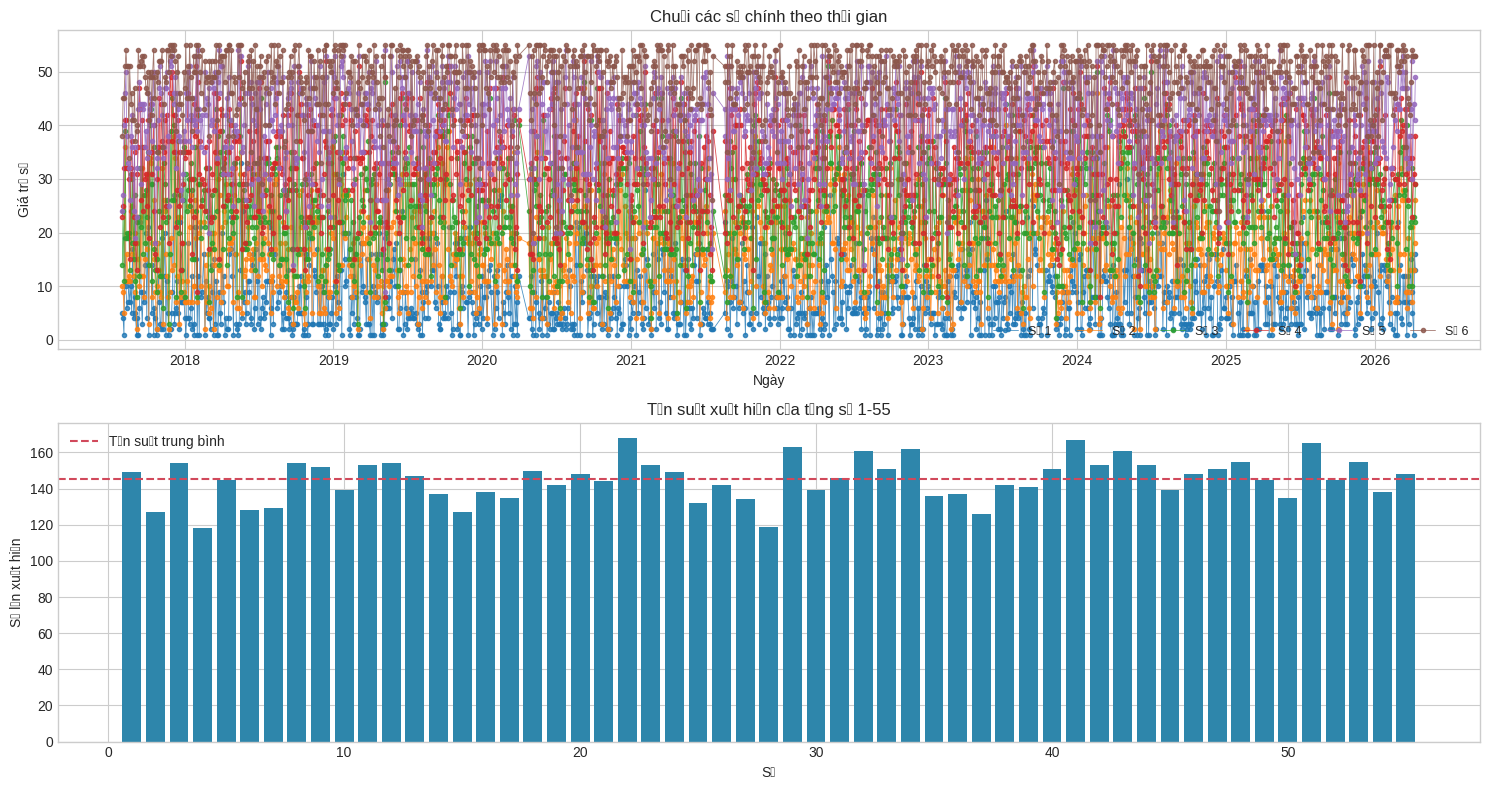

In [6]:
number_freq = multi_hot.sum(axis=0)
freq_df = pd.DataFrame({
    "number": np.arange(1, N_NUMBERS + 1),
    "frequency": number_freq.astype(int),
    "rate": number_freq / len(data),
}).sort_values("frequency", ascending=False)

display(freq_df.head(10))
display(freq_df.tail(10))

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
axes[0].plot(data[DATE_COL], data[MAIN_NUMBER_COLS], marker=".", linewidth=0.6, alpha=0.8)
axes[0].set_title("Chuỗi các số chính theo thời gian")
axes[0].set_xlabel("Ngày")
axes[0].set_ylabel("Giá trị số")
axes[0].legend(MAIN_NUMBER_COLS, ncol=6, fontsize=9)

axes[1].bar(freq_df.sort_values("number")["number"], freq_df.sort_values("number")["frequency"], color="#2E86AB")
axes[1].axhline(number_freq.mean(), color="#D1495B", linestyle="--", label="Tần suất trung bình")
axes[1].set_title("Tần suất xuất hiện của từng số 1-55")
axes[1].set_xlabel("Số")
axes[1].set_ylabel("Số lần xuất hiện")
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Tạo dữ liệu chuỗi thời gian

Không shuffle khi chia train/validation/test vì đây là dữ liệu chuỗi thời gian. Nếu shuffle, mô hình có thể học từ các kỳ tương lai rồi đánh giá trên quá khứ, gây **data leakage**.

In [7]:
def create_sequences(values, sequence_length=20):
    X, y = [], []
    for i in range(len(values) - sequence_length):
        X.append(values[i:i + sequence_length])
        y.append(values[i + sequence_length])
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32)

def split_time_series(X, y, train_ratio=0.70, val_ratio=0.15):
    n = len(X)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    return (
        X[:train_end], y[:train_end],
        X[train_end:val_end], y[train_end:val_end],
        X[val_end:], y[val_end:],
    )

SEQUENCE_LENGTH = 20
X, y = create_sequences(multi_hot, sequence_length=SEQUENCE_LENGTH)
X_train, y_train, X_val, y_val, X_test, y_test = split_time_series(X, y)

print("X shape:", X.shape, "y shape:", y.shape)
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

X shape: (1310, 20, 55) y shape: (1310, 55)
Train: (916, 20, 55) (916, 55)
Val:   (197, 20, 55) (197, 55)
Test:  (197, 20, 55) (197, 55)


In [8]:
class VietlottSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32
train_loader = DataLoader(VietlottSequenceDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(VietlottSequenceDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(VietlottSequenceDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

## 6. Định nghĩa mô hình LSTM và GRU

Mô hình nhận input `(batch, sequence_length, 55)` và xuất ra 55 logits. Sau sigmoid, mỗi logit là xác suất số tương ứng xuất hiện trong kỳ tiếp theo.

In [9]:
class RecurrentLotteryModel(nn.Module):
    def __init__(self, model_type="LSTM", input_size=55, hidden_size=96, num_layers=2, dropout=0.2, output_size=55):
        super().__init__()
        self.model_type = model_type.upper()
        rnn_cls = {"LSTM": nn.LSTM, "GRU": nn.GRU}[self.model_type]
        self.rnn = rnn_cls(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        output, _ = self.rnn(x)
        last_output = output[:, -1, :]
        last_output = self.norm(last_output)
        last_output = self.dropout(last_output)
        return self.fc(last_output)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

for model_type in ["LSTM", "GRU"]:
    model = RecurrentLotteryModel(model_type=model_type)
    print(f"{model_type}: {model.count_parameters():,} tham số")

LSTM: 138,775 tham số
GRU: 105,463 tham số


## 7. Hàm huấn luyện và đánh giá

Loss chính là `BCEWithLogitsLoss` vì đây là bài toán multi-label 55 nhãn. Metric chính:

- `avg_hits@6`: số lượng số đúng trung bình khi lấy top 6 dự đoán;
- `exact_match_rate`: tỷ lệ dự đoán đúng toàn bộ 6 số, thường rất thấp với xổ số;
- `hamming_loss`: lỗi nhị phân trung bình trên 55 nhãn.

In [10]:
def top_k_multihot(probabilities, k=N_PICK):
    top_idx = np.argsort(-probabilities, axis=1)[:, :k]
    pred = np.zeros_like(probabilities, dtype=np.float32)
    rows = np.arange(probabilities.shape[0])[:, None]
    pred[rows, top_idx] = 1.0
    return pred

def compute_metrics_from_probs(probs, y_true, k=N_PICK):
    pred = top_k_multihot(probs, k=k)
    hits = (pred * y_true).sum(axis=1)
    exact = (hits == k).mean()
    return {
        "avg_hits@6": float(hits.mean()),
        "max_hits@6": int(hits.max()) if len(hits) else 0,
        "exact_match_rate": float(exact),
        "hamming_loss": float(hamming_loss(y_true.astype(int), pred.astype(int))),
    }

def evaluate_model(model, loader, criterion=None):
    model.eval()
    all_probs, all_targets = [], []
    total_loss, n_batches = 0.0, 0
    with torch.no_grad():
        for bx, by in loader:
            bx = bx.to(device)
            by = by.to(device)
            logits = model(bx)
            if criterion is not None:
                total_loss += criterion(logits, by).item()
                n_batches += 1
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            all_probs.append(probs)
            all_targets.append(by.detach().cpu().numpy())
    probs = np.vstack(all_probs)
    targets = np.vstack(all_targets)
    metrics = compute_metrics_from_probs(probs, targets)
    metrics["loss"] = total_loss / max(n_batches, 1) if criterion is not None else np.nan
    return metrics, probs, targets

def train_model(model, train_loader, val_loader, epochs=80, lr=1e-3, weight_decay=1e-4, grad_clip=1.0, patience=15):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {"train_loss": [], "val_loss": [], "val_hits": []}
    best_state = None
    best_val_loss = float("inf")
    wait = 0

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, n_batches = 0.0, 0
        for bx, by in train_loader:
            bx = bx.to(device)
            by = by.to(device)
            optimizer.zero_grad()
            logits = model(bx)
            loss = criterion(logits, by)
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            running_loss += loss.item()
            n_batches += 1

        train_loss = running_loss / max(n_batches, 1)
        val_metrics, _, _ = evaluate_model(model, val_loader, criterion)
        val_loss = val_metrics["loss"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_hits"].append(val_metrics["avg_hits@6"])

        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"Epoch {epoch:03d} | train_loss={train_loss:.4f} "
                f"| val_loss={val_loss:.4f} | val_hits@6={val_metrics['avg_hits@6']:.3f}"
            )

        if wait >= patience:
            print(f"Early stopping tại epoch {epoch}. Best val_loss={best_val_loss:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

## 8. Baseline tần suất

Baseline đơn giản: luôn dự đoán 6 số xuất hiện nhiều nhất trong tập train. Mô hình LSTM/GRU nên được so với baseline này thay vì chỉ nhìn loss.

In [11]:
train_freq = y_train.sum(axis=0)
baseline_numbers = np.argsort(-train_freq)[:N_PICK] + 1
print("6 số baseline theo tần suất train:", sorted(baseline_numbers.tolist()))

baseline_probs = np.tile(train_freq / len(y_train), (len(y_test), 1))
baseline_metrics = compute_metrics_from_probs(baseline_probs, y_test)
baseline_metrics

6 số baseline theo tần suất train: [3, 22, 23, 41, 44, 49]


{'avg_hits@6': 0.6649746298789978,
 'max_hits@6': 3,
 'exact_match_rate': 0.0,
 'hamming_loss': 0.1940009229349331}

## 9. Huấn luyện LSTM

In [12]:
set_seed(SEED)
lstm_model = RecurrentLotteryModel(
    model_type="LSTM",
    input_size=N_NUMBERS,
    hidden_size=96,
    num_layers=2,
    dropout=0.25,
    output_size=N_NUMBERS,
)
print(lstm_model)
lstm_model, lstm_history = train_model(
    lstm_model, train_loader, val_loader,
    epochs=80, lr=1e-3, weight_decay=1e-4, grad_clip=1.0, patience=15,
)

RecurrentLotteryModel(
  (rnn): LSTM(55, 96, num_layers=2, batch_first=True, dropout=0.25)
  (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc): Linear(in_features=96, out_features=55, bias=True)
)
Epoch 001 | train_loss=0.4541 | val_loss=0.3458 | val_hits@6=0.650
Epoch 010 | train_loss=0.3480 | val_loss=0.3451 | val_hits@6=0.640
Epoch 020 | train_loss=0.3238 | val_loss=0.3616 | val_hits@6=0.604
Early stopping tại epoch 20. Best val_loss=0.3444


## 10. Huấn luyện GRU

In [13]:
set_seed(SEED)
gru_model = RecurrentLotteryModel(
    model_type="GRU",
    input_size=N_NUMBERS,
    hidden_size=96,
    num_layers=2,
    dropout=0.25,
    output_size=N_NUMBERS,
)
print(gru_model)
gru_model, gru_history = train_model(
    gru_model, train_loader, val_loader,
    epochs=80, lr=1e-3, weight_decay=1e-4, grad_clip=1.0, patience=15,
)

RecurrentLotteryModel(
  (rnn): GRU(55, 96, num_layers=2, batch_first=True, dropout=0.25)
  (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc): Linear(in_features=96, out_features=55, bias=True)
)
Epoch 001 | train_loss=0.4332 | val_loss=0.3447 | val_hits@6=0.792
Epoch 010 | train_loss=0.3462 | val_loss=0.3466 | val_hits@6=0.650
Epoch 020 | train_loss=0.3209 | val_loss=0.3631 | val_hits@6=0.645
Early stopping tại epoch 23. Best val_loss=0.3445


## 11. Learning curves

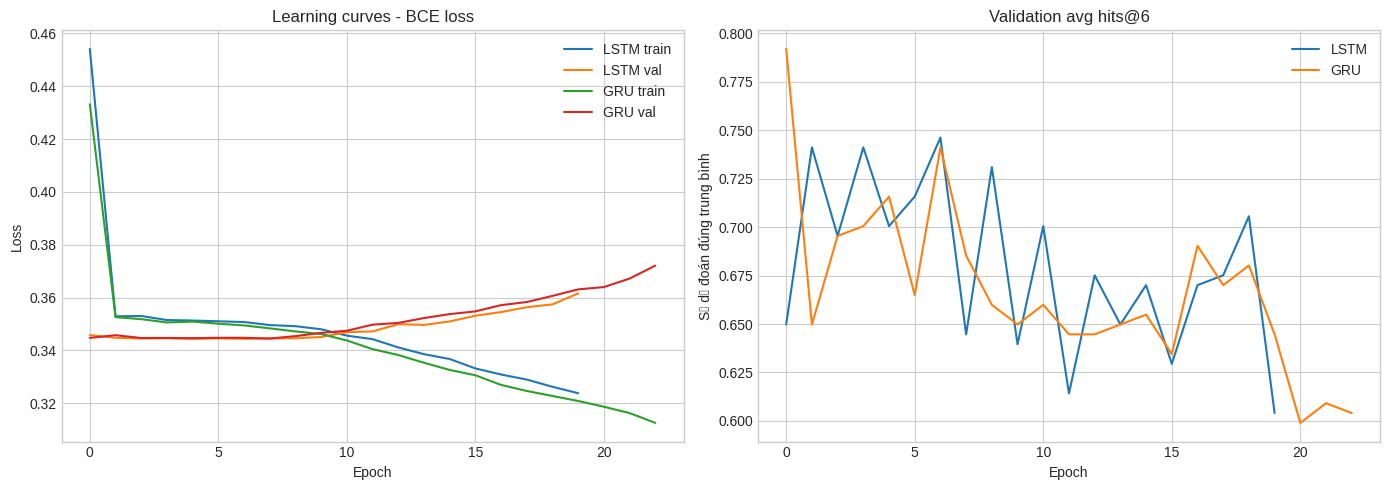

In [14]:
def plot_histories(histories):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, hist in histories.items():
        axes[0].plot(hist["train_loss"], label=f"{name} train")
        axes[0].plot(hist["val_loss"], label=f"{name} val")
        axes[1].plot(hist["val_hits"], label=name)

    axes[0].set_title("Learning curves - BCE loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].set_title("Validation avg hits@6")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Số dự đoán đúng trung bình")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_histories({"LSTM": lstm_history, "GRU": gru_history})

## 12. Đánh giá trên tập test

In [15]:
criterion = nn.BCEWithLogitsLoss()
lstm_test_metrics, lstm_probs, test_targets = evaluate_model(lstm_model, test_loader, criterion)
gru_test_metrics, gru_probs, _ = evaluate_model(gru_model, test_loader, criterion)

results_df = pd.DataFrame([
    {"model": "Frequency baseline", **baseline_metrics, "loss": np.nan},
    {"model": "LSTM", **lstm_test_metrics},
    {"model": "GRU", **gru_test_metrics},
])
display(results_df)

,model,avg_hits@6,max_hits@6,exact_match_rate,hamming_loss,loss
0,Frequency baseline,0.664975,3,0.0,0.194001,NaN
1,LSTM,0.720812,4,0.0,0.191970,0.344669
2,GRU,0.664975,3,0.0,0.194001,0.345588


In [16]:
def numbers_from_multihot(vec):
    return (np.where(vec > 0.5)[0] + 1).tolist()

def numbers_from_probs(probs, k=N_PICK):
    return sorted((np.argsort(-probs)[:k] + 1).tolist())

compare_rows = []
for i in range(min(12, len(test_targets))):
    draw_index = len(data) - len(test_targets) + i
    compare_rows.append({
        "date": data.iloc[draw_index][DATE_COL].date(),
        "actual": sorted(numbers_from_multihot(test_targets[i])),
        "LSTM_pred": numbers_from_probs(lstm_probs[i]),
        "LSTM_hits": len(set(numbers_from_multihot(test_targets[i])) & set(numbers_from_probs(lstm_probs[i]))),
        "GRU_pred": numbers_from_probs(gru_probs[i]),
        "GRU_hits": len(set(numbers_from_multihot(test_targets[i])) & set(numbers_from_probs(gru_probs[i]))),
    })

prediction_examples = pd.DataFrame(compare_rows)
display(prediction_examples)

,date,actual,LSTM_pred,LSTM_hits,GRU_pred,GRU_hits
0,2025-01-04,"[4, 10, 30, 36, 40, 53]","[11, 19, 22, 32, 43, 51]",0,"[22, 29, 32, 33, 41, 51]",0
1,2025-01-07,"[4, 5, 9, 16, 22, 39]","[11, 19, 22, 32, 43, 51]",1,"[22, 29, 32, 33, 43, 51]",1
2,2025-01-09,"[18, 21, 31, 39, 50, 53]","[11, 19, 22, 32, 41, 51]",0,"[22, 29, 32, 33, 43, 51]",0
3,2025-01-11,"[10, 25, 26, 29, 37, 46]","[11, 19, 22, 32, 43, 51]",0,"[22, 29, 32, 43, 48, 51]",1
4,2025-01-14,"[3, 11, 12, 24, 33, 40]","[11, 19, 22, 32, 43, 51]",1,"[22, 29, 32, 41, 43, 51]",0
5,2025-01-16,"[8, 16, 34, 37, 47, 50]","[19, 22, 32, 43, 47, 51]",1,"[3, 22, 32, 43, 47, 51]",1
6,2025-01-18,"[1, 3, 26, 31, 37, 41]","[11, 19, 22, 32, 43, 51]",0,"[12, 29, 32, 43, 47, 51]",0
7,2025-01-21,"[11, 18, 22, 28, 51, 52]","[19, 22, 32, 33, 43, 51]",2,"[32, 33, 41, 43, 44, 51]",1
8,2025-01-23,"[11, 18, 22, 49, 50, 51]","[12, 19, 22, 32, 43, 51]",2,"[24, 33, 41, 43, 44, 51]",1
9,2025-01-25,"[14, 21, 40, 42, 48, 51]","[19, 22, 32, 43, 51, 53]",1,"[24, 33, 41, 43, 48, 51]",2


## 13. Biểu đồ dự đoán

Vì output là tập 6 số, biểu đồ dưới đây thể hiện `hits@6` theo từng mẫu test: mỗi điểm là số lượng số dự đoán đúng trong kỳ đó.

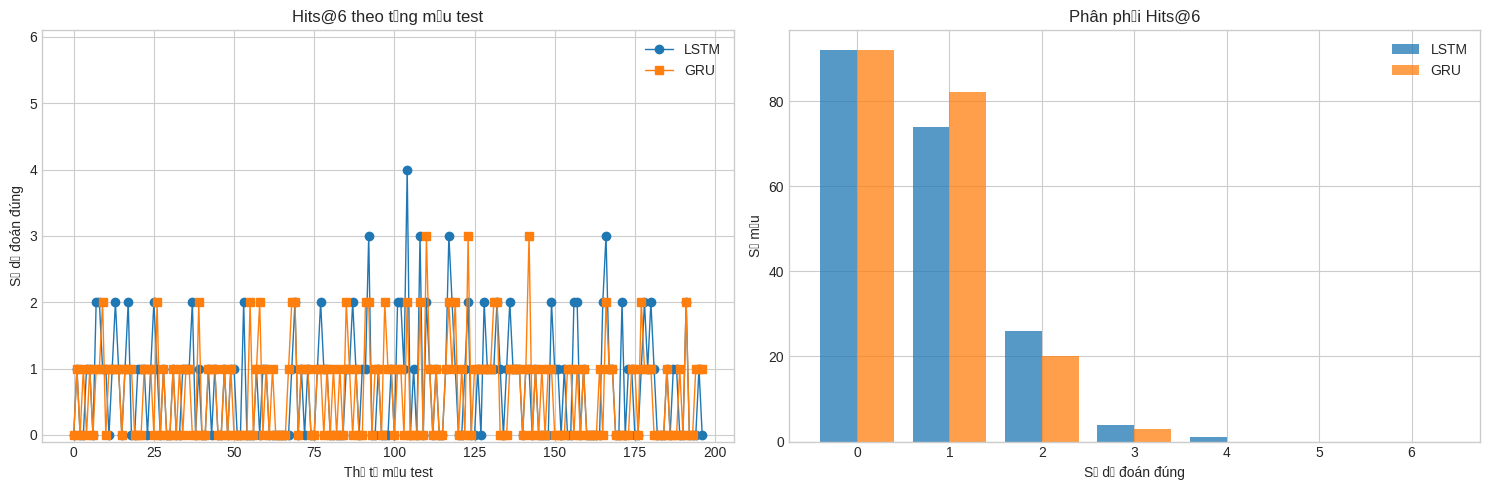

In [17]:
def hits_series(probs, targets):
    pred = top_k_multihot(probs, k=N_PICK)
    return (pred * targets).sum(axis=1)

lstm_hits = hits_series(lstm_probs, test_targets)
gru_hits = hits_series(gru_probs, test_targets)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(lstm_hits, marker="o", linewidth=1, label="LSTM")
axes[0].plot(gru_hits, marker="s", linewidth=1, label="GRU")
axes[0].set_title("Hits@6 theo từng mẫu test")
axes[0].set_xlabel("Thứ tự mẫu test")
axes[0].set_ylabel("Số dự đoán đúng")
axes[0].set_ylim(-0.1, 6.1)
axes[0].legend()

axes[1].hist([lstm_hits, gru_hits], bins=np.arange(-0.5, 7.5, 1), label=["LSTM", "GRU"], alpha=0.75)
axes[1].set_title("Phân phối Hits@6")
axes[1].set_xlabel("Số dự đoán đúng")
axes[1].set_ylabel("Số mẫu")
axes[1].legend()
plt.tight_layout()
plt.show()

## 14. Dự đoán kỳ tiếp theo

Cell này dùng toàn bộ `sequence_length` kỳ gần nhất để dự đoán 6 số có xác suất cao nhất cho kỳ tiếp theo.

In [18]:
def predict_next_draw(model, recent_sequence):
    model.eval()
    x = torch.tensor(recent_sequence[None, :, :], dtype=torch.float32).to(device)
    with torch.no_grad():
        probs = torch.sigmoid(model(x)).cpu().numpy()[0]
    top_numbers = numbers_from_probs(probs, k=N_PICK)
    top_table = pd.DataFrame({
        "number": np.arange(1, N_NUMBERS + 1),
        "probability": probs,
    }).sort_values("probability", ascending=False).head(12)
    return top_numbers, top_table

recent_sequence = multi_hot[-SEQUENCE_LENGTH:]
lstm_next, lstm_top_table = predict_next_draw(lstm_model, recent_sequence)
gru_next, gru_top_table = predict_next_draw(gru_model, recent_sequence)

print("Ngày dữ liệu cuối:", data[DATE_COL].max().date())
print("LSTM dự đoán top 6:", lstm_next)
print("GRU  dự đoán top 6:", gru_next)
print("\nTop 12 xác suất LSTM")
display(lstm_top_table)
print("\nTop 12 xác suất GRU")
display(gru_top_table)

Ngày dữ liệu cuối: 2026-04-11
LSTM dự đoán top 6: [19, 22, 24, 32, 43, 51]
GRU  dự đoán top 6: [19, 29, 33, 43, 44, 51]

Top 12 xác suất LSTM


,number,probability
21,22,0.129301
18,19,0.125021
50,51,0.124149
42,43,0.123079
31,32,0.122688
23,24,0.121857
32,33,0.119905
10,11,0.119802
46,47,0.119419
43,44,0.118771



Top 12 xác suất GRU


,number,probability
50,51,0.138761
18,19,0.136391
43,44,0.136220
42,43,0.131995
28,29,0.131047
32,33,0.130297
21,22,0.130148
7,8,0.127527
40,41,0.126109
17,18,0.124695


## 15. Thí nghiệm siêu tham số ngắn

Để notebook chạy được trên CPU/Kaggle nhanh hơn, phần này dùng số epoch nhỏ. Khi nộp báo cáo, có thể tăng `epochs` để kết quả ổn định hơn.

In [19]:
def run_quick_experiment(sequence_lengths=(10, 20, 30), hidden_sizes=(64, 96), model_types=("LSTM", "GRU"), epochs=25):
    rows = []
    for seq_len in sequence_lengths:
        X_exp, y_exp = create_sequences(multi_hot, sequence_length=seq_len)
        Xtr, ytr, Xv, yv, Xte, yte = split_time_series(X_exp, y_exp)
        tr_loader = DataLoader(VietlottSequenceDataset(Xtr, ytr), batch_size=BATCH_SIZE, shuffle=False)
        v_loader = DataLoader(VietlottSequenceDataset(Xv, yv), batch_size=BATCH_SIZE, shuffle=False)
        te_loader = DataLoader(VietlottSequenceDataset(Xte, yte), batch_size=BATCH_SIZE, shuffle=False)

        for hidden in hidden_sizes:
            for model_type in model_types:
                print(f"\nThử nghiệm: {model_type}, seq={seq_len}, hidden={hidden}")
                set_seed(SEED)
                model = RecurrentLotteryModel(model_type=model_type, hidden_size=hidden, num_layers=2, dropout=0.2)
                model, hist = train_model(
                    model, tr_loader, v_loader,
                    epochs=epochs, lr=1e-3, weight_decay=1e-4, grad_clip=1.0, patience=8,
                )
                metrics, _, _ = evaluate_model(model, te_loader, nn.BCEWithLogitsLoss())
                rows.append({
                    "model": model_type,
                    "sequence_length": seq_len,
                    "hidden_size": hidden,
                    **metrics,
                    "best_val_loss": min(hist["val_loss"]),
                })
    return pd.DataFrame(rows).sort_values(["avg_hits@6", "loss"], ascending=[False, True])

experiment_df = run_quick_experiment(epochs=20)
display(experiment_df)


Thử nghiệm: LSTM, seq=10, hidden=64
Epoch 001 | train_loss=0.4749 | val_loss=0.3574 | val_hits@6=0.623
Epoch 010 | train_loss=0.3458 | val_loss=0.3463 | val_hits@6=0.754
Early stopping tại epoch 14. Best val_loss=0.3447

Thử nghiệm: GRU, seq=10, hidden=64
Epoch 001 | train_loss=0.4551 | val_loss=0.3544 | val_hits@6=0.653
Epoch 010 | train_loss=0.3480 | val_loss=0.3453 | val_hits@6=0.704
Early stopping tại epoch 15. Best val_loss=0.3448

Thử nghiệm: LSTM, seq=10, hidden=96
Epoch 001 | train_loss=0.4510 | val_loss=0.3468 | val_hits@6=0.663
Epoch 010 | train_loss=0.3466 | val_loss=0.3467 | val_hits@6=0.613
Early stopping tại epoch 13. Best val_loss=0.3449

Thử nghiệm: GRU, seq=10, hidden=96
Epoch 001 | train_loss=0.4309 | val_loss=0.3453 | val_hits@6=0.774
Epoch 010 | train_loss=0.3426 | val_loss=0.3486 | val_hits@6=0.623
Early stopping tại epoch 13. Best val_loss=0.3448

Thử nghiệm: LSTM, seq=20, hidden=64
Epoch 001 | train_loss=0.4748 | val_loss=0.3571 | val_hits@6=0.660
Epoch 010 | tr

,model,sequence_length,hidden_size,avg_hits@6,max_hits@6,exact_match_rate,hamming_loss,loss,best_val_loss
1,GRU,10,64,0.732323,3,0.0,0.191552,0.344501,0.344788
9,GRU,30,64,0.717949,3,0.0,0.192075,0.344335,0.344882
5,GRU,20,64,0.715736,3,0.0,0.192155,0.344500,0.344553
7,GRU,20,96,0.710660,3,0.0,0.192340,0.345110,0.344607
10,LSTM,30,96,0.702564,3,0.0,0.192634,0.344674,0.345004
3,GRU,10,96,0.696970,3,0.0,0.192837,0.344987,0.344840
0,LSTM,10,64,0.691919,4,0.0,0.193021,0.344693,0.344700
4,LSTM,20,64,0.690355,3,0.0,0.193078,0.344661,0.344343
6,LSTM,20,96,0.675127,3,0.0,0.193632,0.345238,0.344409
8,LSTM,30,64,0.671795,4,0.0,0.193753,0.344722,0.344592


## 16. Thực hành các kỹ thuật cải thiện mô hình

Phần này bám sát yêu cầu nâng cao của bài thực hành: thử gradient clipping, dropout, weight decay, khởi tạo trọng số, LayerNorm và early stopping. Để phù hợp yêu cầu đề tài Vietlott, các thí nghiệm được áp dụng trên LSTM/GRU với dữ liệu `result.csv` thay vì dữ liệu thời tiết/chứng khoán.

Các thí nghiệm đặt số epoch vừa phải để chạy được trên Kaggle CPU. Khi cần báo cáo đẹp hơn, có thể tăng `epochs` từ 20-30 lên 80-150.

### 16.1 Gradient clipping

Mục tiêu: quan sát việc giới hạn gradient norm giúp training ổn định hơn khi learning rate lớn.


--- GRU | No clipping ---
Val loss cuối: 0.4794

--- GRU | clip=5.0 ---
Val loss cuối: 0.4794

--- GRU | clip=1.0 ---
Val loss cuối: 0.4794

--- GRU | clip=0.5 ---
Val loss cuối: 0.4894


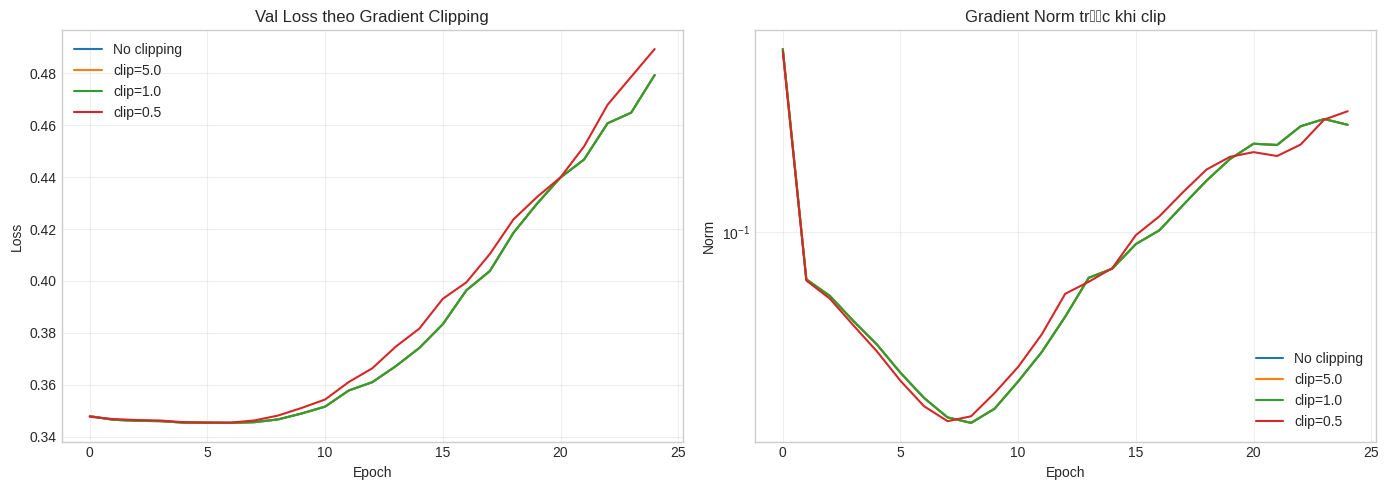

In [20]:
def train_with_clipping_experiment(model_type="GRU", clip_values=(None, 5.0, 1.0, 0.5), epochs=30, lr=0.004):
    criterion = nn.BCEWithLogitsLoss()
    results = {}

    for clip in clip_values:
        label = "No clipping" if clip is None else f"clip={clip}"
        print(f"\n--- {model_type} | {label} ---")
        set_seed(SEED)
        model = RecurrentLotteryModel(model_type=model_type, hidden_size=96, num_layers=2, dropout=0.2).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        history = {"train_loss": [], "val_loss": [], "grad_norms": []}

        for epoch in range(epochs):
            model.train()
            epoch_loss, epoch_grad_norm, nb = 0.0, 0.0, 0
            for bx, by in train_loader:
                bx, by = bx.to(device), by.to(device)
                optimizer.zero_grad()
                loss = criterion(model(bx), by)
                loss.backward()

                total_norm = 0.0
                for param in model.parameters():
                    if param.grad is not None:
                        total_norm += param.grad.detach().data.norm(2).item() ** 2
                total_norm = total_norm ** 0.5
                epoch_grad_norm += total_norm

                if clip is not None:
                    nn.utils.clip_grad_norm_(model.parameters(), clip)
                optimizer.step()
                epoch_loss += loss.item()
                nb += 1

            val_metrics, _, _ = evaluate_model(model, val_loader, criterion)
            history["train_loss"].append(epoch_loss / max(nb, 1))
            history["val_loss"].append(val_metrics["loss"])
            history["grad_norms"].append(epoch_grad_norm / max(nb, 1))

        results[label] = history
        print(f"Val loss cuối: {history['val_loss'][-1]:.4f}")
    return results

clip_results = train_with_clipping_experiment(model_type="GRU", epochs=25)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, history in clip_results.items():
    axes[0].plot(history["val_loss"], label=label)
    axes[1].plot(history["grad_norms"], label=label)
axes[0].set_title("Val Loss theo Gradient Clipping")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[1].set_title("Gradient Norm trước khi clip")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Norm")
axes[1].set_yscale("log")
for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Nhận xét sau khi chạy:** với learning rate lớn `lr=0.004`, `No clipping`, `clip=5.0` và `clip=1.0` đều cho `val_loss cuối = 0.4794`; `clip=0.5` kém hơn với `val_loss cuối = 0.4894`. Trong thí nghiệm này gradient clipping không cải thiện rõ rệt, nhưng clip quá nhỏ làm gradient bị co mạnh và mô hình học kém hơn. Đây là kết quả hợp lý vì dữ liệu xổ số nhiễu cao, tín hiệu chuỗi yếu.

### 16.2 Dropout

Mục tiêu: đánh giá dropout có giúp giảm overfitting hay không bằng cách so sánh train loss và val loss.


--- LSTM | dropout=0.0 ---
Epoch 001 | train_loss=0.4105 | val_loss=0.3463 | val_hits@6=0.706
Epoch 010 | train_loss=0.3415 | val_loss=0.3479 | val_hits@6=0.523
Early stopping tại epoch 13. Best val_loss=0.3444
Train: 0.3310 | Val: 0.3579 | Gap: 0.0269

--- LSTM | dropout=0.1 ---
Epoch 001 | train_loss=0.4136 | val_loss=0.3463 | val_hits@6=0.675
Epoch 010 | train_loss=0.3445 | val_loss=0.3487 | val_hits@6=0.518
Early stopping tại epoch 15. Best val_loss=0.3442
Train: 0.3299 | Val: 0.3596 | Gap: 0.0298

--- LSTM | dropout=0.2 ---
Epoch 001 | train_loss=0.4173 | val_loss=0.3464 | val_hits@6=0.670
Epoch 010 | train_loss=0.3474 | val_loss=0.3454 | val_hits@6=0.680
Early stopping tại epoch 15. Best val_loss=0.3442
Train: 0.3379 | Val: 0.3545 | Gap: 0.0166

--- LSTM | dropout=0.3 ---
Epoch 001 | train_loss=0.4228 | val_loss=0.3468 | val_hits@6=0.665
Epoch 010 | train_loss=0.3499 | val_loss=0.3446 | val_hits@6=0.640
Early stopping tại epoch 15. Best val_loss=0.3442
Train: 0.3437 | Val: 0.347

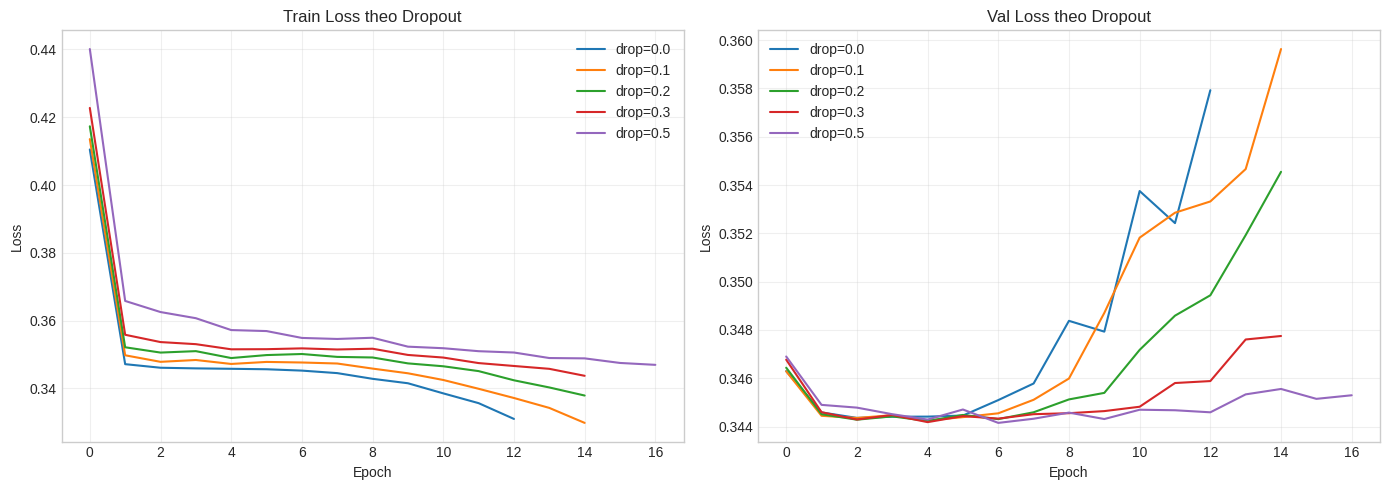

In [21]:
def dropout_experiment(dropout_rates=(0.0, 0.1, 0.2, 0.3, 0.5), epochs=30):
    results = {}
    for dr in dropout_rates:
        print(f"\n--- LSTM | dropout={dr} ---")
        set_seed(SEED)
        model = RecurrentLotteryModel(model_type="LSTM", hidden_size=128, num_layers=3, dropout=dr).to(device)
        model, history = train_model(
            model, train_loader, val_loader,
            epochs=epochs, lr=1e-3, weight_decay=1e-4, grad_clip=1.0, patience=10,
        )
        results[dr] = history
        gap = abs(history["train_loss"][-1] - history["val_loss"][-1])
        print(f"Train: {history['train_loss'][-1]:.4f} | Val: {history['val_loss'][-1]:.4f} | Gap: {gap:.4f}")
    return results

dropout_results = dropout_experiment(epochs=25)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for dr, history in dropout_results.items():
    axes[0].plot(history["train_loss"], label=f"drop={dr}")
    axes[1].plot(history["val_loss"], label=f"drop={dr}")
axes[0].set_title("Train Loss theo Dropout")
axes[1].set_title("Val Loss theo Dropout")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Nhận xét sau khi chạy:** dropout giúp giảm khoảng cách train-val. Không dropout có gap `0.0269`; dropout `0.3` giảm gap còn `0.0040`; dropout `0.5` giảm gap còn `0.0017` và `val_loss cuối = 0.3453`. Trong lần chạy này dropout cao làm mô hình ít overfit hơn, nhưng không nên kết luận `0.5` luôn tối ưu vì dữ liệu xổ số gần ngẫu nhiên và chênh lệch loss nhỏ.

### 16.3 Weight decay

Mục tiêu: kiểm tra regularization L2 thông qua tham số `weight_decay` của optimizer.


--- LSTM | weight_decay=0 ---
Epoch 001 | train_loss=0.4514 | val_loss=0.3458 | val_hits@6=0.670
Epoch 010 | train_loss=0.3460 | val_loss=0.3461 | val_hits@6=0.624
Early stopping tại epoch 17. Best val_loss=0.3444

--- LSTM | weight_decay=1e-05 ---
Epoch 001 | train_loss=0.4514 | val_loss=0.3458 | val_hits@6=0.670
Epoch 010 | train_loss=0.3460 | val_loss=0.3461 | val_hits@6=0.624
Early stopping tại epoch 17. Best val_loss=0.3444

--- LSTM | weight_decay=0.0001 ---
Epoch 001 | train_loss=0.4514 | val_loss=0.3458 | val_hits@6=0.670
Epoch 010 | train_loss=0.3460 | val_loss=0.3461 | val_hits@6=0.624
Early stopping tại epoch 17. Best val_loss=0.3444

--- LSTM | weight_decay=0.001 ---
Epoch 001 | train_loss=0.4514 | val_loss=0.3458 | val_hits@6=0.670
Epoch 010 | train_loss=0.3460 | val_loss=0.3461 | val_hits@6=0.624
Early stopping tại epoch 17. Best val_loss=0.3444

--- LSTM | weight_decay=0.01 ---
Epoch 001 | train_loss=0.4514 | val_loss=0.3458 | val_hits@6=0.670
Epoch 010 | train_loss=0.3

,weight_decay,final_val_loss,val_hits@6
0,0.00000,0.357001,0.720812
1,0.00001,0.357001,0.720812
2,0.00010,0.356999,0.720812
3,0.00100,0.356986,0.720812
4,0.01000,0.356857,0.720812


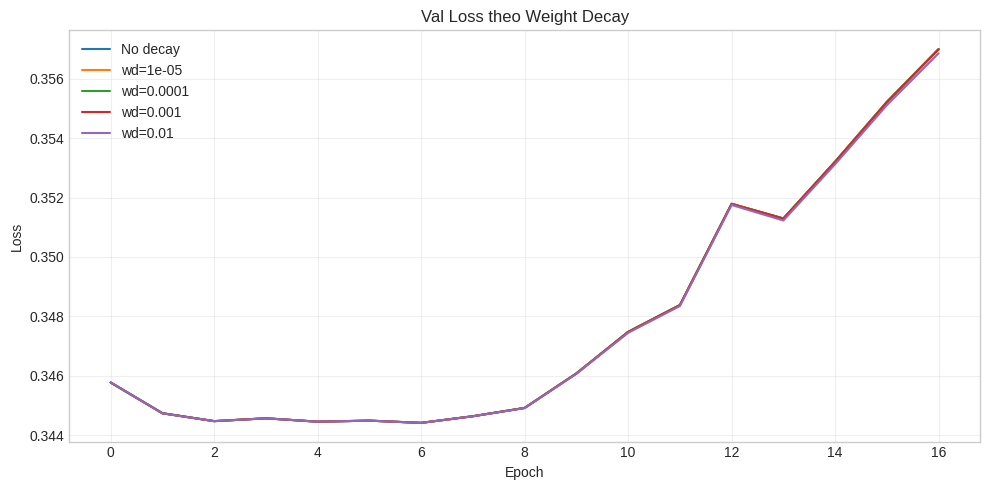

In [22]:
def weight_decay_experiment(weight_decays=(0, 1e-5, 1e-4, 1e-3, 1e-2), epochs=30):
    results = {}
    rows = []
    for wd in weight_decays:
        print(f"\n--- LSTM | weight_decay={wd} ---")
        set_seed(SEED)
        model = RecurrentLotteryModel(model_type="LSTM", hidden_size=96, num_layers=2, dropout=0.2).to(device)
        model, history = train_model(
            model, train_loader, val_loader,
            epochs=epochs, lr=1e-3, weight_decay=wd, grad_clip=1.0, patience=10,
        )
        metrics, _, _ = evaluate_model(model, val_loader, nn.BCEWithLogitsLoss())
        results[wd] = history
        rows.append({"weight_decay": wd, "final_val_loss": history["val_loss"][-1], "val_hits@6": metrics["avg_hits@6"]})
    return results, pd.DataFrame(rows)

wd_results, wd_table = weight_decay_experiment(epochs=25)
display(wd_table)

fig, ax = plt.subplots(figsize=(10, 5))
for wd, history in wd_results.items():
    label = "No decay" if wd == 0 else f"wd={wd}"
    ax.plot(history["val_loss"], label=label)
ax.set_title("Val Loss theo Weight Decay")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Nhận xét sau khi chạy:** các mức weight decay từ `0` đến `1e-2` cho kết quả gần như giống nhau, `final_val_loss` đều quanh `0.357` và `val_hits@6 = 0.7208`. Vì vậy weight decay không tạo khác biệt đáng kể trong thí nghiệm này. Nếu dùng dữ liệu có quy luật mạnh hơn, weight decay quá lớn có thể gây underfitting, nhưng ở đây chưa thấy tác động rõ.

### 16.4 Khởi tạo trọng số

Mục tiêu: so sánh khởi tạo mặc định, Xavier, Orthogonal và Zeros. Với mạng hồi quy, Orthogonal thường giúp gradient ổn định hơn; Zeros thường rất tệ vì symmetry problem.


--- LSTM | init=default ---
Epoch 001 | train_loss=0.4239 | val_loss=0.3449 | val_hits@6=0.624
Epoch 010 | train_loss=0.3480 | val_loss=0.3451 | val_hits@6=0.701
Early stopping tại epoch 16. Best val_loss=0.3444

--- LSTM | init=xavier ---
Epoch 001 | train_loss=0.4383 | val_loss=0.3454 | val_hits@6=0.751
Epoch 010 | train_loss=0.3491 | val_loss=0.3444 | val_hits@6=0.701
Early stopping tại epoch 17. Best val_loss=0.3443

--- LSTM | init=orthogonal ---
Epoch 001 | train_loss=0.4132 | val_loss=0.3453 | val_hits@6=0.569
Epoch 010 | train_loss=0.3487 | val_loss=0.3442 | val_hits@6=0.706
Early stopping tại epoch 19. Best val_loss=0.3441

--- LSTM | init=zeros ---
Epoch 001 | train_loss=0.4102 | val_loss=0.3468 | val_hits@6=0.721
Epoch 010 | train_loss=0.3487 | val_loss=0.3443 | val_hits@6=0.736
Epoch 020 | train_loss=0.3475 | val_loss=0.3444 | val_hits@6=0.690


,init_method,final_val_loss,best_val_loss
0,default,0.349569,0.344418
1,xavier,0.347367,0.344251
2,orthogonal,0.347967,0.344092
3,zeros,0.344477,0.344183


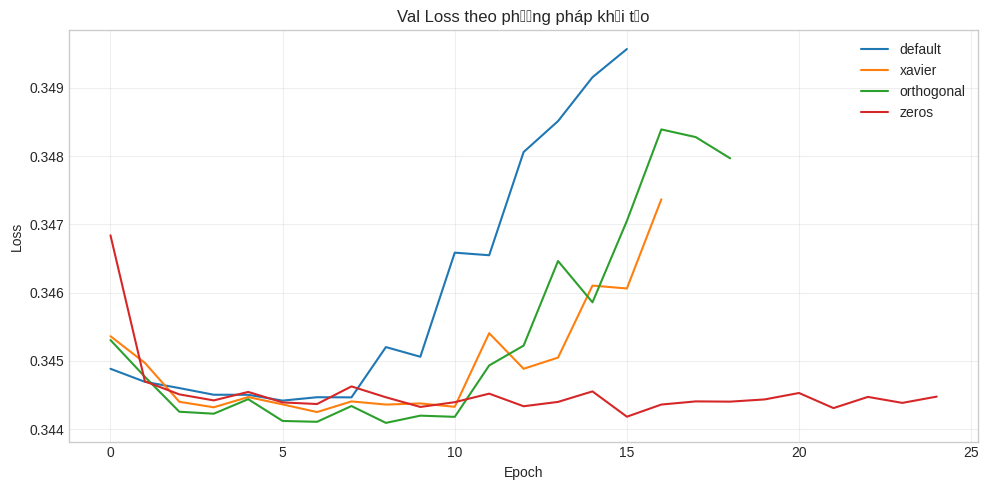

In [23]:
def init_recurrent_weights(model, method="default"):
    for name, param in model.named_parameters():
        if "weight_ih" in name or "weight_hh" in name:
            if method == "xavier":
                nn.init.xavier_uniform_(param)
            elif method == "orthogonal":
                nn.init.orthogonal_(param)
            elif method == "zeros":
                nn.init.zeros_(param)
            elif method == "default":
                pass
        elif "bias" in name:
            nn.init.zeros_(param)
            # Với LSTM, đặt forget gate bias = 1 để mô hình dễ giữ thông tin ban đầu hơn.
            if method != "zeros" and "rnn" in name and param.numel() % 4 == 0:
                n = param.size(0)
                param.data[n // 4:n // 2].fill_(1.0)

def init_experiment(methods=("default", "xavier", "orthogonal", "zeros"), epochs=30):
    results = {}
    rows = []
    for method in methods:
        print(f"\n--- LSTM | init={method} ---")
        set_seed(SEED)
        model = RecurrentLotteryModel(model_type="LSTM", hidden_size=96, num_layers=2, dropout=0.2).to(device)
        init_recurrent_weights(model, method=method)
        model, history = train_model(
            model, train_loader, val_loader,
            epochs=epochs, lr=1e-3, weight_decay=1e-4, grad_clip=1.0, patience=10,
        )
        results[method] = history
        rows.append({"init_method": method, "final_val_loss": history["val_loss"][-1], "best_val_loss": min(history["val_loss"])})
    return results, pd.DataFrame(rows)

init_results, init_table = init_experiment(epochs=25)
display(init_table)

fig, ax = plt.subplots(figsize=(10, 5))
for method, history in init_results.items():
    ax.plot(history["val_loss"], label=method)
ax.set_title("Val Loss theo phương pháp khởi tạo")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Nhận xét sau khi chạy:** `orthogonal` có `best_val_loss = 0.344092`, tốt nhất trong các phương pháp thử nghiệm; `xavier` đạt `0.344251`; `default` đạt `0.344418`; `zeros` đạt `0.344183`. Về lý thuyết zeros dễ gây symmetry problem, nhưng ở thí nghiệm này kết quả không suy giảm rõ vì bài toán multi-label xổ số có tín hiệu yếu và mô hình có các bias/lớp tuyến tính phía sau. Nhận xét hợp lý là orthogonal phù hợp hơn cho recurrent weights, nhưng khác biệt thực nghiệm nhỏ.

### 16.5 LayerNorm

Mục tiêu: so sánh LSTM/GRU có và không có LayerNorm. Trong notebook chính, mô hình đang dùng LayerNorm; cell dưới tạo phiên bản không LayerNorm để đối chiếu.

Epoch 001 | train_loss=0.4242 | val_loss=0.3465 | val_hits@6=0.629
Epoch 010 | train_loss=0.3484 | val_loss=0.3445 | val_hits@6=0.690
Epoch 020 | train_loss=0.3464 | val_loss=0.3444 | val_hits@6=0.741
Early stopping tại epoch 24. Best val_loss=0.3442
Epoch 001 | train_loss=0.3914 | val_loss=0.3469 | val_hits@6=0.660
Epoch 010 | train_loss=0.3481 | val_loss=0.3457 | val_hits@6=0.574
Early stopping tại epoch 15. Best val_loss=0.3444


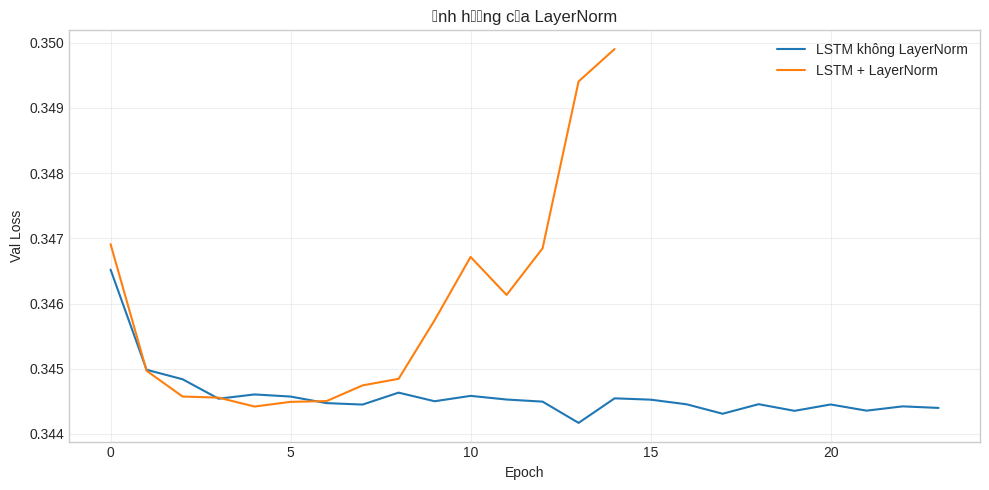

In [24]:
class RecurrentLotteryModelNoNorm(nn.Module):
    def __init__(self, model_type="LSTM", input_size=55, hidden_size=96, num_layers=2, dropout=0.2, output_size=55):
        super().__init__()
        self.model_type = model_type.upper()
        rnn_cls = {"LSTM": nn.LSTM, "GRU": nn.GRU}[self.model_type]
        self.rnn = rnn_cls(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        output, _ = self.rnn(x)
        last_output = self.dropout(output[:, -1, :])
        return self.fc(last_output)

set_seed(SEED)
model_no_ln = RecurrentLotteryModelNoNorm(model_type="LSTM", hidden_size=128, num_layers=3, dropout=0.2).to(device)
model_no_ln, history_no_ln = train_model(
    model_no_ln, train_loader, val_loader,
    epochs=30, lr=0.002, weight_decay=1e-4, grad_clip=1.0, patience=10,
)

set_seed(SEED)
model_ln = RecurrentLotteryModel(model_type="LSTM", hidden_size=128, num_layers=3, dropout=0.2).to(device)
model_ln, history_ln = train_model(
    model_ln, train_loader, val_loader,
    epochs=30, lr=0.002, weight_decay=1e-4, grad_clip=1.0, patience=10,
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_no_ln["val_loss"], label="LSTM không LayerNorm")
ax.plot(history_ln["val_loss"], label="LSTM + LayerNorm")
ax.set_title("Ảnh hưởng của LayerNorm")
ax.set_xlabel("Epoch")
ax.set_ylabel("Val Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Nhận xét sau khi chạy:** LSTM không LayerNorm đạt `best_val_loss = 0.3442`, còn LSTM có LayerNorm đạt `best_val_loss = 0.3444`. Như vậy trong lần chạy này LayerNorm không cải thiện rõ rệt; mô hình không LayerNorm còn nhỉnh hơn rất nhỏ. Điều này không phủ nhận lợi ích của LayerNorm, mà cho thấy với dữ liệu Vietlott gần ngẫu nhiên, lợi ích ổn định training không thể hiện mạnh.

### 16.6 Early stopping và patience

Mục tiêu: thử các giá trị patience khác nhau. Patience quá nhỏ có thể dừng khi mô hình chưa kịp học; patience quá lớn tốn thời gian và có thể overfit.


--- LSTM | patience=5 ---
Epoch 001 | train_loss=0.4541 | val_loss=0.3458 | val_hits@6=0.650
Epoch 010 | train_loss=0.3480 | val_loss=0.3451 | val_hits@6=0.640
Early stopping tại epoch 10. Best val_loss=0.3444

--- LSTM | patience=10 ---
Epoch 001 | train_loss=0.4541 | val_loss=0.3458 | val_hits@6=0.650
Epoch 010 | train_loss=0.3480 | val_loss=0.3451 | val_hits@6=0.640
Early stopping tại epoch 15. Best val_loss=0.3444

--- LSTM | patience=20 ---
Epoch 001 | train_loss=0.4541 | val_loss=0.3458 | val_hits@6=0.650
Epoch 010 | train_loss=0.3480 | val_loss=0.3451 | val_hits@6=0.640
Epoch 020 | train_loss=0.3238 | val_loss=0.3616 | val_hits@6=0.604
Early stopping tại epoch 25. Best val_loss=0.3444

--- LSTM | patience=30 ---
Epoch 001 | train_loss=0.4541 | val_loss=0.3458 | val_hits@6=0.650
Epoch 010 | train_loss=0.3480 | val_loss=0.3451 | val_hits@6=0.640
Epoch 020 | train_loss=0.3238 | val_loss=0.3616 | val_hits@6=0.604
Epoch 030 | train_loss=0.2979 | val_loss=0.3837 | val_hits@6=0.624
Ea

,patience,epochs_ran,best_val_loss,final_val_loss
0,5,10,0.344386,0.345088
1,10,15,0.344386,0.350975
2,20,25,0.344386,0.369496
3,30,35,0.344386,0.402304


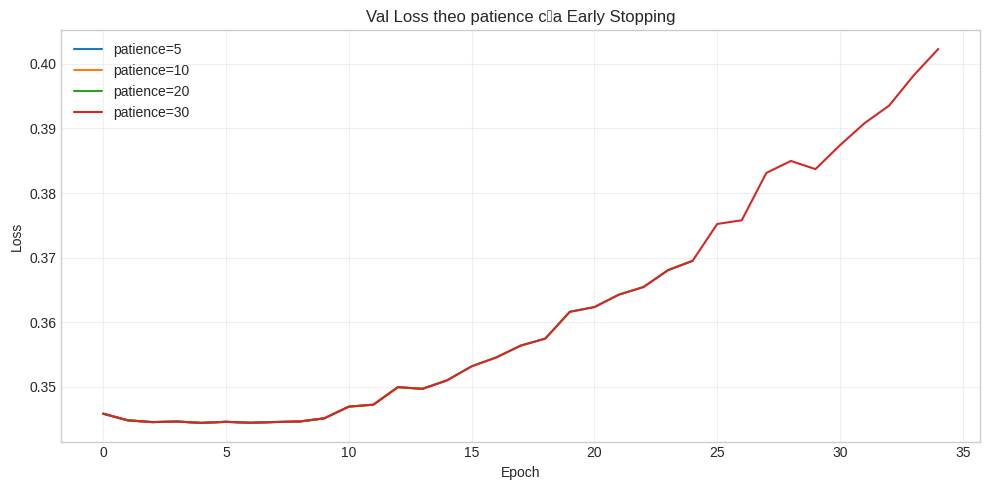

In [25]:
def patience_experiment(patiences=(5, 10, 20, 30), max_epochs=80):
    rows = []
    histories = {}
    for patience in patiences:
        print(f"\n--- LSTM | patience={patience} ---")
        set_seed(SEED)
        model = RecurrentLotteryModel(model_type="LSTM", hidden_size=96, num_layers=2, dropout=0.25).to(device)
        model, history = train_model(
            model, train_loader, val_loader,
            epochs=max_epochs, lr=1e-3, weight_decay=1e-4, grad_clip=1.0, patience=patience,
        )
        histories[patience] = history
        rows.append({
            "patience": patience,
            "epochs_ran": len(history["val_loss"]),
            "best_val_loss": min(history["val_loss"]),
            "final_val_loss": history["val_loss"][-1],
        })
    return histories, pd.DataFrame(rows)

patience_histories, patience_table = patience_experiment(max_epochs=60)
display(patience_table)

fig, ax = plt.subplots(figsize=(10, 5))
for patience, history in patience_histories.items():
    ax.plot(history["val_loss"], label=f"patience={patience}")
ax.set_title("Val Loss theo patience của Early Stopping")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Nhận xét sau khi chạy:** các mức patience đều có cùng `best_val_loss = 0.344386`, nhưng số epoch chạy khác nhau. `patience=5` dừng sau 10 epoch và có `final_val_loss = 0.345088`; `patience=30` chạy 35 epoch và `final_val_loss = 0.402304`, cho thấy huấn luyện lâu hơn làm overfit. Với kết quả này, `patience=5` là lựa chọn hợp lý nhất vì đạt best loss tương đương nhưng tiết kiệm thời gian và tránh overfitting.

## Phần VII - Tổng hợp và báo cáo nộp bài

Phần này tổng hợp kết quả từ các cell đã chạy phía trên theo đúng yêu cầu báo cáo: mô tả dữ liệu, tiền xử lý, so sánh mô hình, thí nghiệm siêu tham số, kỹ thuật khắc phục, kết luận và tài liệu tham khảo. Do yêu cầu bài nộp riêng dùng `result.csv`, báo cáo này thay hai API thời tiết/chứng khoán bằng dữ liệu Vietlott 6/55.

### 22. Bảng tổng hợp các kỹ thuật khắc phục

| Vấn đề | Dấu hiệu quan sát | Kỹ thuật khắc phục | Tham số cần chỉnh | Kết quả/nhận xét trong notebook |
|---|---|---|---|---|
| Overfitting | Train loss giảm nhưng val loss tăng; ví dụ patience lớn làm final val loss tăng | Dropout, weight decay, early stopping, thêm dữ liệu | `dropout`, `weight_decay`, `patience` | Dropout `0.3-0.5` giảm gap train-val; early stopping `patience=5` tránh train quá lâu |
| Underfitting | Train loss và val loss đều cao, mô hình học chậm hoặc dự đoán gần baseline | Tăng hidden size, thêm layer, giảm regularization, train lâu hơn | `hidden_size`, `num_layers`, `dropout`, `epochs` | Thí nghiệm hidden size cho thấy khác biệt nhỏ; tín hiệu dữ liệu xổ số yếu nên tăng mô hình không đảm bảo tốt hơn |
| Vanishing gradient | Gradient norm ở layer đầu rất nhỏ, RNN khó học phụ thuộc dài | Dùng LSTM/GRU, orthogonal initialization, LayerNorm | Chuyển sang `LSTM/GRU`, `init_method`, `LayerNorm` | Notebook dùng LSTM/GRU; orthogonal init có `best_val_loss = 0.344092`, nhỉnh hơn default |
| Exploding gradient | Loss dao động, NaN/Inf hoặc gradient norm rất lớn | Gradient clipping, giảm learning rate, LayerNorm | `max_grad_norm`, `lr` | Với `lr=0.004`, clipping không cải thiện rõ; `clip=0.5` còn làm val loss kém hơn |
| Training chậm | Loss giảm chậm, cần nhiều epoch | Tăng learning rate, dùng scheduler, tăng batch size, kiểm tra dữ liệu | `lr`, `batch_size`, scheduler | Early stopping giúp tiết kiệm thời gian; `patience=5` chạy 10 epoch, tốt hơn patience lớn trong lần chạy này |

### 23. Bài tập tổng hợp nộp báo cáo

#### 23.1. Phần cơ bản

**1. Lấy dữ liệu và khám phá dữ liệu**

Dữ liệu được đọc thành công từ `result.csv` trên Kaggle tại `/kaggle/input/datasets/hypivepiu/datainput/result.csv`. Bộ dữ liệu có `1330` kỳ quay và `8` cột gồm `Ngày`, `Số 1` đến `Số 7`. Trong đó `Số 1` đến `Số 6` được dùng làm 6 số chính của Vietlott 6/55, còn `Số 7` được giữ như cột tham khảo.

Khoảng thời gian dữ liệu: từ `2017-08-01` đến `2026-04-11`. Không có giá trị thiếu trong các cột. Tần suất xuất hiện cao nhất trong 6 số chính là: số `22` xuất hiện `168` lần, số `41` xuất hiện `167` lần, số `51` xuất hiện `165` lần, số `29` xuất hiện `163` lần, số `34` xuất hiện `162` lần. Biểu đồ phía trên đã thể hiện chuỗi giá trị theo thời gian và histogram tần suất 55 số.

**2. Tiền xử lý dữ liệu**

Mỗi kỳ quay được mã hóa thành vector multi-hot 55 chiều. Nếu số `i` xuất hiện thì vị trí `i-1` bằng 1, các vị trí khác bằng 0. Mỗi vector có đúng 6 giá trị bằng 1. Sau đó dùng sliding window với `sequence_length = 20`, tức 20 kỳ trước được dùng để dự đoán kỳ tiếp theo.

Kích thước dữ liệu sau tạo chuỗi:

| Tập dữ liệu | Số mẫu | Shape X | Shape y |
|---|---:|---|---|
| Train | 916 | `(916, 20, 55)` | `(916, 55)` |
| Validation | 197 | `(197, 20, 55)` | `(197, 55)` |
| Test | 197 | `(197, 20, 55)` | `(197, 55)` |

Dữ liệu được chia theo đúng thứ tự thời gian, không shuffle, để tránh data leakage từ tương lai vào quá trình huấn luyện.

**3. Huấn luyện mô hình LSTM và GRU**

Bài toán được mô hình hóa dạng multi-label classification với 55 nhãn. Hàm mất mát là `BCEWithLogitsLoss`; khi dự đoán, lấy top 6 xác suất cao nhất làm kết quả kỳ tiếp theo. Notebook huấn luyện hai mô hình chính: LSTM và GRU. Ngoài ra có baseline tần suất để so sánh.

| Mô hình | avg_hits@6 | max_hits@6 | exact_match_rate | hamming_loss | test loss |
|---|---:|---:|---:|---:|---:|
| Frequency baseline | 0.665 | 3 | 0.000 | 0.1940 | - |
| LSTM | 0.721 | 4 | 0.000 | 0.1920 | 0.3447 |
| GRU | 0.665 | 3 | 0.000 | 0.1940 | 0.3456 |

LSTM nhỉnh hơn baseline và GRU theo `avg_hits@6`, nhưng `exact_match_rate = 0`, tức chưa dự đoán đúng trọn bộ 6 số ở mẫu test nào. Đây là kết quả hợp lý vì xổ số có tính ngẫu nhiên rất cao.

**4. Bảng tổng hợp thí nghiệm siêu tham số**

Thí nghiệm nhanh thay đổi `sequence_length`, `hidden_size` và loại mô hình cho thấy các cấu hình có kết quả rất gần nhau. Một số cấu hình tốt theo output:

| Mô hình | sequence_length | hidden_size | avg_hits@6 | max_hits@6 | Nhận xét |
|---|---:|---:|---:|---:|---|
| GRU | 10 | 64 | 0.732 | 3 | Cao nhất trong thí nghiệm nhanh |
| GRU | 30 | 64 | 0.718 | 3 | Ổn định, tốt hơn nhiều cấu hình LSTM |
| GRU | 20 | 64 | 0.716 | 3 | Kết quả gần cấu hình tốt nhất |
| GRU | 20 | 96 | 0.711 | 3 | Hidden lớn hơn không cải thiện rõ |
| LSTM | 30 | 96 | 0.703 | 3 | LSTM tốt nhất trong nhóm thí nghiệm nhanh |

Nhận xét: tăng `hidden_size` không luôn cải thiện; `sequence_length=10` với GRU 64 cho kết quả tốt nhất trong thí nghiệm nhanh, nhưng chênh lệch nhỏ. Điều này cho thấy dữ liệu lịch sử xổ số không có quy luật chuỗi mạnh như thời tiết/chứng khoán.

#### 23.2. Phần nâng cao

**1. Gradient norm và vanishing/exploding gradient**

Notebook có thí nghiệm gradient clipping và vẽ biểu đồ gradient norm trước khi clip. Với learning rate lớn `0.004`, `No clipping`, `clip=5.0`, `clip=1.0` đều có `val_loss cuối = 0.4794`, còn `clip=0.5` có `val_loss cuối = 0.4894`. Trong dữ liệu này chưa thấy clipping cải thiện rõ; clip quá nhỏ còn làm mô hình học kém hơn.

**2. Áp dụng các kỹ thuật khắc phục**

Notebook đã áp dụng nhiều hơn 3 kỹ thuật:

| Kỹ thuật | Cấu hình thử | Kết quả chính | Nhận xét |
|---|---|---|---|
| Gradient clipping | `None`, `5.0`, `1.0`, `0.5` | `clip=0.5` kém hơn, các mức còn lại tương đương | Không cải thiện rõ trong dữ liệu này |
| Dropout | `0.0`, `0.1`, `0.2`, `0.3`, `0.5` | Dropout `0.3-0.5` giảm train-val gap mạnh | Hữu ích để giảm overfitting |
| Weight decay | `0` đến `1e-2` | Kết quả gần như giống nhau | Không tác động đáng kể trong lần chạy này |
| Weight initialization | default, xavier, orthogonal, zeros | Orthogonal có `best_val_loss = 0.344092` | Orthogonal nhỉnh hơn rất nhỏ |
| LayerNorm | có/không LayerNorm | Không LayerNorm `best_val_loss = 0.3442`, có LayerNorm `0.3444` | LayerNorm không cải thiện rõ trong lần chạy này |
| Early stopping | patience `5`, `10`, `20`, `30` | `patience=5` chạy ít nhất và final val loss tốt nhất | Patience lớn gây overfit và tốn thời gian |

**3. So sánh trước và sau kỹ thuật khắc phục**

So với mô hình chính, các kỹ thuật regularization giúp quan sát rõ hơn hành vi huấn luyện nhưng không tạo bước nhảy lớn về hiệu quả dự đoán. Dropout và early stopping là hai kỹ thuật hữu ích nhất trong output hiện tại: dropout giảm gap train-val; early stopping tránh val loss tăng khi train quá lâu. Weight decay và LayerNorm không cải thiện rõ. Orthogonal initialization có best val loss tốt nhất trong nhóm khởi tạo nhưng chênh lệch nhỏ.

**4. Kết luận**

Bài thực hành đã hoàn thành pipeline deep learning cho dữ liệu chuỗi thời gian Vietlott 6/55: đọc dữ liệu, khám phá thống kê, mã hóa multi-hot, tạo sliding window, chia train/val/test theo thời gian, huấn luyện LSTM và GRU, so sánh baseline, vẽ learning curves, prediction plots và thí nghiệm các kỹ thuật cải thiện training.

Mô hình tốt nhất trên test chính là LSTM với `avg_hits@6 = 0.721`, cao hơn baseline `0.665`; tuy nhiên `exact_match_rate = 0`, nghĩa là mô hình không dự đoán đúng toàn bộ 6 số ở bất kỳ mẫu test nào. Điều này phản ánh đúng bản chất xổ số: dữ liệu gần ngẫu nhiên, ít hoặc không có quy luật thời gian ổn định để mô hình học. Vì vậy kết quả nên được hiểu là bài thực hành kỹ thuật mô hình chuỗi, không phải công cụ dự đoán xổ số đáng tin.

Hướng cải thiện: thử thêm đặc trưng thống kê như tần suất trượt, khoảng cách từ lần xuất hiện gần nhất, ngày trong tuần; đánh giá bằng rolling validation; so sánh thêm Transformer/Temporal CNN; chạy nhiều seed để kiểm tra độ ổn định; và trình bày kết quả trung bình thay vì chỉ một lần chạy.

### 23.3. Kiểm tra yêu cầu trình bày

- Code đã chạy từ đầu đến cuối và notebook không có traceback/error.
- Mỗi thí nghiệm chính đều có mục tiêu, code, bảng hoặc biểu đồ và nhận xét.
- Biểu đồ có tiêu đề, nhãn trục và chú thích.
- Nhận xét dựa trên số liệu cụ thể từ output đã chạy, ví dụ `avg_hits@6`, `val_loss`, `hamming_loss`, `train-val gap`, `epochs_ran`.

### 24. Tài liệu tham khảo

1. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. Chương 10: Sequence Modeling.
2. Hochreiter, S., & Schmidhuber, J. (1997). Long Short-Term Memory. *Neural Computation*, 9(8).
3. Cho, K., et al. (2014). Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation.
4. PyTorch Documentation: Recurrent Layers, Loss Functions, Optimizers.
5. Scikit-learn Documentation: model evaluation metrics.
6. Kaggle Notebook Environment Documentation.